In [10]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

import warnings
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model selection
from sklearn.model_selection import train_test_split

# Metrics — used for confusion matrix, ROC curve, PR curve, goodness-of-fit
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, precision_score, recall_score, f1_score
)

# Models
from sklearn.svm import LinearSVC

# SHAP — for model interpretability analysis
import shap

# Deep learning
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

# LightGBM
import lightgbm as lgb

# NLP & APIs
from openai import OpenAI
from dotenv import load_dotenv, dotenv_values
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import lyricsgenius

# Utilities
import re, pickle, time, base64, requests
from tqdm import tqdm

In [18]:
# Refer 'Final Model and Datasets' folder in 'Collab Workspace' section of Drive for datasets used and notebook in the same place
# Can be run on Google Colab

path = '550k-spotify-songs-audio-lyrics-and-genres'
mirex_path = 'MIREX-like_mood/dataset'

## Section 1: Data Loading & Genre Balancing
Load 550K song dataset and balance to 12,000 songs per genre (120K total).

In [7]:
df = pd.read_csv(f"{path}/songs.csv")

In [14]:
print(df[['id', 'lyrics', 'danceability', 'energy', 'genre']].isnull().sum())

id              0
lyrics          0
danceability    0
energy          0
genre           0
dtype: int64


In [15]:
print(df['genre'].value_counts())

genre
Rock          197168
Pop            72539
Electronic     69755
Folk           50843
Country        46076
Hip-Hop        41745
R&B            27337
Jazz           17010
Blues          15976
Classical      12173
Name: count, dtype: int64


In [16]:
print(f"\nTotal genres: {df['genre'].nunique()}")


Total genres: 10


In [25]:
SONGS_PER_GENRE = 12000

df_balanced = pd.concat([group.sample(SONGS_PER_GENRE, random_state=42) for _, group in df.groupby('genre')])\
    .reset_index(drop=True)

In [26]:
print(len(df_balanced))                     # 120,000
print(df_balanced['genre'].value_counts())  # 12,000 each

audio_cols = ['danceability', 'energy', 'key', 'loudness', 'mode',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo', 'duration_ms']

df_balanced = df_balanced[['id', 'name', 'artists', 'lyrics', 'genre'] + audio_cols]
df_balanced.to_csv(f"{path}/moodsense_100k_balanced.csv", index=False)

120000
genre
Blues         12000
Classical     12000
Country       12000
Electronic    12000
Folk          12000
Hip-Hop       12000
Jazz          12000
Pop           12000
R&B           12000
Rock          12000
Name: count, dtype: int64


In [27]:
df['approx_tokens'] = df['lyrics'].str.len() / 4

print(df['approx_tokens'].describe())
print(f"\nSongs exceeding 8192 token limit: {(df['approx_tokens'] > 8192).sum()}")
all_tokens = 0
for tokens in df['approx_tokens']:
    all_tokens += tokens

print(round(all_tokens/550622*120000,0))

count    550622.000000
mean        317.197451
std         197.361850
min           0.500000
25%         192.250000
50%         275.250000
75%         383.250000
max        6834.500000
Name: approx_tokens, dtype: float64

Songs exceeding 8192 token limit: 0
38063694.0


## Section 2: API Setup & Lyric Embedding (512d)
Embed lyrics using OpenAI `text-embedding-3-small` at 512 dimensions.  
Batch size = 100 to stay under the 300K token/request limit.  
Checkpoint saved every 5,000 songs to allow resume on interruption.

In [21]:
load_dotenv(f"{path}/.env")

True

In [23]:
client = OpenAI(api_key=dotenv_values(f"{path}/.env")['OPENAI_API_KEY'])

In [54]:
print(f"Embedding {len(df_balanced)} songs")
lyrics = df_balanced['lyrics'].fillna('').tolist()

Embedding 120000 songs


In [28]:
# Config
BATCH_SIZE = 500
DIMS = 512
SAVE_EVERY = 10          # checkpoint every 5,000 songs
CHECKPOINT = f"{path}/embeddings_checkpoint.npy"

In [31]:
all_embeddings = []
start_batch = 0

if os.path.exists(CHECKPOINT):
    all_embeddings = list(np.load(CHECKPOINT))
    start_batch = len(all_embeddings) // BATCH_SIZE
    print(f"Resuming from song {len(all_embeddings)}")

Resuming from song 120000


In [57]:
batches = [lyrics[i:i+BATCH_SIZE] for i in range(0, len(lyrics), BATCH_SIZE)]

for i, batch in enumerate(batches[start_batch:], start=start_batch):
    while True:
        try:
            response = client.embeddings.create(
                model="text-embedding-3-small",
                input=batch,
                dimensions=DIMS)
            all_embeddings.extend([e.embedding for e in response.data])
            break
        except Exception as e:
            print(f"Error on batch {i}, retrying in 10s: {e}")
            time.sleep(10)

    if (i + 1) % SAVE_EVERY == 0:
        np.save(CHECKPOINT, np.array(all_embeddings))
        print(f"Progress: {len(all_embeddings)}/{len(lyrics)} songs ({len(all_embeddings)/len(lyrics)*100:.1f}%)")

Progress: 5000/120000 songs (4.2%)
Progress: 10000/120000 songs (8.3%)
Progress: 15000/120000 songs (12.5%)
Progress: 20000/120000 songs (16.7%)
Progress: 25000/120000 songs (20.8%)
Progress: 30000/120000 songs (25.0%)
Progress: 35000/120000 songs (29.2%)
Progress: 40000/120000 songs (33.3%)
Progress: 45000/120000 songs (37.5%)
Progress: 50000/120000 songs (41.7%)
Progress: 55000/120000 songs (45.8%)
Progress: 60000/120000 songs (50.0%)
Error on batch 120, retrying in 10s: Error code: 400 - {'error': {'message': 'Requested 340768 tokens, max 300000 tokens per request', 'type': 'max_tokens_per_request', 'param': None, 'code': 'max_tokens_per_request'}}


NameError: name 'time' is not defined

In [29]:
lyrics_truncated = [str(l)[:2000] for l in df_balanced['lyrics'].fillna('').tolist()]

In [32]:
BATCH_SIZE = 100  # 100 songs × 500 tokens = 50K tokens per request (safe)
batches = [lyrics_truncated[i:i+BATCH_SIZE] for i in range(0, len(lyrics_truncated), BATCH_SIZE)]
start_batch = len(all_embeddings) // 100

print(f"Resuming from batch {start_batch}/{len(batches)}")

Resuming from batch 1200/1200


In [62]:
for i, batch in enumerate(batches[start_batch:], start=start_batch):
    while True:
        try:
            response = client.embeddings.create(
                model="text-embedding-3-small",
                input=batch,
                dimensions=DIMS)
            all_embeddings.extend([e.embedding for e in response.data])
            break
        except Exception as e:
            print(f"Error on batch {i}, retrying in 10s: {e}")
            time.sleep(10)

    if (i + 1) % SAVE_EVERY == 0:
        np.save(CHECKPOINT, np.array(all_embeddings))
        print(f"Progress: {len(all_embeddings)}/{len(lyrics)} songs ({len(all_embeddings)/len(lyrics)*100:.1f}%)")

Progress: 61000/120000 songs (50.8%)
Progress: 62000/120000 songs (51.7%)
Progress: 63000/120000 songs (52.5%)
Progress: 64000/120000 songs (53.3%)
Progress: 65000/120000 songs (54.2%)
Progress: 66000/120000 songs (55.0%)
Progress: 67000/120000 songs (55.8%)
Progress: 68000/120000 songs (56.7%)
Progress: 69000/120000 songs (57.5%)
Progress: 70000/120000 songs (58.3%)
Progress: 71000/120000 songs (59.2%)
Progress: 72000/120000 songs (60.0%)
Progress: 73000/120000 songs (60.8%)
Progress: 74000/120000 songs (61.7%)
Progress: 75000/120000 songs (62.5%)
Progress: 76000/120000 songs (63.3%)
Progress: 77000/120000 songs (64.2%)
Progress: 78000/120000 songs (65.0%)
Progress: 79000/120000 songs (65.8%)
Progress: 80000/120000 songs (66.7%)
Progress: 81000/120000 songs (67.5%)
Progress: 82000/120000 songs (68.3%)
Progress: 83000/120000 songs (69.2%)
Progress: 84000/120000 songs (70.0%)
Progress: 85000/120000 songs (70.8%)
Progress: 86000/120000 songs (71.7%)
Progress: 87000/120000 songs (72.5%)
P

In [33]:
text_embeddings = np.load(f"{path}/embeddings_checkpoint.npy")                                                                                                                                                                                  
print(f"Text embeddings shape: {text_embeddings.shape}")

Text embeddings shape: (120000, 512)


## Section 3: Audio Feature Scaling & Combined Matrix (524d)
Scale 12 Spotify audio features with StandardScaler.  
Concatenate: text_512d + audio_12d = 524d combined feature matrix.  
Save scaler to `audio_scaler.pkl` for use in the inference pipeline.

In [34]:
audio_cols = ['danceability', 'energy', 'key', 'loudness', 'mode',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo', 'duration_ms']

In [35]:
scaler = StandardScaler()
audio_scaled = scaler.fit_transform(df_balanced[audio_cols])
print(f"Audio features shape: {audio_scaled.shape}")

Audio features shape: (120000, 12)


In [36]:
combined = np.hstack([text_embeddings, audio_scaled])
print(f"Combined shape: {combined.shape}")

Combined shape: (120000, 524)


In [69]:
np.save(f"{path}/combined_embeddings_120k.npy", combined)

In [71]:
with open(f"{path}/audio_scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

## Section 4: MIREX Dataset Processing
MIREX: 903 songs, 5 mood clusters, human-annotated from audio listening.  
Note: song 782 is missing from `dataset info.csv` — drop index 781 from cluster/category lists.

In [37]:
files = os.listdir(mirex_path)
print(sorted(files)[:20])

['.DS_Store', 'Audio', 'Lyrics', 'MIDIs', 'categories.txt', 'clusters.txt', 'dataset info.csv', 'dataset info.html', 'split-by-categories-audio.bat', 'split-by-categories-lyrics.bat', 'split-by-categories-midi.bat']


In [38]:
with open(f'{mirex_path}/clusters.txt') as f:
    clusters = f.read().splitlines()
print(f"\nTotal cluster labels: {len(clusters)}")
print(f"Unique clusters: {set(clusters)}")


Total cluster labels: 903
Unique clusters: {'Cluster 4', 'Cluster 1', 'Cluster 3', 'Cluster 2', 'Cluster 5'}


In [39]:
with open(f'{mirex_path}/categories.txt') as f:
    categories = f.read().splitlines()
print(f"\nSample categories: {np.random.choice(categories,10)}")
print("All unique categories:", set(categories))


Sample categories: ['Fun' 'Witty' 'Intense' 'Fiery' 'Rollicking' 'Humorous' 'Humorous'
 'Brooding' 'Sweet' 'Cheerful']
All unique categories: {'Silly', 'Confident', 'Visceral', 'Boisterous', 'Amiable-good natured', 'Sweet', 'Wry', 'Fun', 'Wistful', 'Humorous', 'Witty', 'Brooding', 'Poignant', 'Autumnal', 'Intense', 'Passionate', 'Campy', 'Fiery', 'Rousing', 'Volatile', 'Bittersweet', 'whimsical', 'Literate', 'Tense - Anxious', 'Agressive', 'Rowdy', 'Rollicking', 'Cheerful'}


In [40]:
df_mirex_info = pd.read_csv(f'{mirex_path}/dataset info.csv', encoding='utf-16', sep=';',\
                            on_bad_lines='skip').dropna(axis=1, how='all')
print("\nDataset info columns:", df_mirex_info.columns.tolist())
print(df_mirex_info.head(10))


Dataset info columns: ['Title', 'Artist', 'Album', 'Track', 'Year', 'Length', 'Size', 'Last Modified', 'Filename']
                                 Title                             Artist  \
0  (Mama) He Treats Your Daughter Mean                        Brown, Ruth   
1                     Night in Tunisia  Blakey, Art & the Jazz Messengers   
2                     Along Came Jones                           Coasters   
3                        Back in Black                              AC/DC   
4                       Bad Reputation       Jett, Joan & Teh Blackhearts   
5                  Boogie Woogie Stomp                     Ammons, Albert   
6  Burn Rubber (Why You Wanna Hurt Me)                       Gap Band [1]   
7               Cigarettes and Alcohol                              Oasis   
8             Country Grammar (Hot...)                              Nelly   
9                Fairytale of New York             Pogues/MacColl, Kirsty   

                                    

In [41]:
lyrics_files = os.listdir(f'{mirex_path}/Lyrics')
print(f"\nTotal lyric files: {len(lyrics_files)}")
print("Sample filenames:", lyrics_files[:5])


Total lyric files: 764
Sample filenames: ['289.txt', '504.txt', '262.txt', '276.txt', '510.txt']


In [42]:
# Expected song numbers 1-903                                                                                                                                                                                                                   
expected = set(range(1, 904))                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                  
# Actual song numbers in dataset info                                                                                                                                                                                                         
actual = set(df_mirex_info['Filename'].str.replace('.mp3', '').astype(int))

missing = expected - actual
print(f"Missing song number: {missing}")
print(f"Extra in clusters: {len(clusters) - len(df_mirex_info)}")

# Drop the cluster/category at the missing song's position
missing_idx = sorted(missing)[0] - 1  # convert to 0-indexed

clusters_clean = clusters[:missing_idx] + clusters[missing_idx+1:]
categories_clean = list(categories[:missing_idx]) + list(categories[missing_idx+1:])

print(f"Clusters: {len(clusters_clean)}, Categories: {len(categories_clean)}, Info: {len(df_mirex_info)}")

Missing song number: {782}
Extra in clusters: 1
Clusters: 902, Categories: 902, Info: 902


In [43]:
df_mirex = df_mirex_info.copy()
df_mirex['cluster'] = clusters_clean                                                                                                                                                                                                                  
df_mirex['category'] = list(categories_clean)                                                                                                                                                                                                       
df_mirex['song_num'] = df_mirex['Filename'].str.replace('.mp3', '').astype(int)

pd.set_option('display.max_columns', None)                                                                                                                                                                                                      
pd.set_option('display.width', None)    
print(pd.crosstab(df_mirex['cluster'], df_mirex['category']))
print("\nSongs per cluster:")
print(df_mirex['cluster'].value_counts().sort_index())

category   Agressive  Amiable-good natured  Autumnal  Bittersweet  Boisterous  \
cluster                                                                         
Cluster 1          0                     0         0            0          31   
Cluster 2          0                    35         0            0           0   
Cluster 3          0                     0        36           38           0   
Cluster 4          0                     0         0            0           0   
Cluster 5         22                     0         0            0           0   

category   Brooding  Campy  Cheerful  Confident  Fiery  Fun  Humorous  \
cluster                                                                 
Cluster 1         0      0         0         37      0    0         0   
Cluster 2         0      0        32          0      0   29         0   
Cluster 3        36      0         0          0      0    0         0   
Cluster 4         0     38         0          0      0    0        

| Cluster | Categories | Emotion |
  |---|---|---|
  | 1 | Passionate, Rousing, Confident, Boisterous, Rowdy | Love |                                                                                                                                                                                
  | 2 | Amiable, Cheerful, Fun, Rollicking, Sweet | Happy |
  | 3 | Autumnal, Bittersweet, Brooding, Literate, Poignant, Wistful | Sad |                                                                                                                                                                      
  | 4 | Campy, Humorous, Silly, Whimsical, Witty, Wry | Happy |                                                                                                                                                                                 
  | 5 | Aggressive, Fiery, Intense, Tense-Anxious, Visceral, Volatile | Anger |

## Section 5: MIREX Emotion Mapping & Centroid Computation
Map 5 MIREX clusters to 4 emotions: Happy, Sad, Anger, Love.  
Embed 686 MIREX lyrics (512d) and compute per-emotion centroids.  
Centroids serve as human-grounded emotion anchors for labeling the 120K dataset.

In [44]:
cluster_emotion_map = {
    'Cluster 1': 'Love',
    'Cluster 2': 'Happy',
    'Cluster 3': 'Sad',
    'Cluster 4': 'Happy',
    'Cluster 5': 'Anger'
}

df_mirex['emotion'] = df_mirex['cluster'].map(cluster_emotion_map)

print(df_mirex['emotion'].value_counts())

emotion
Happy    355
Sad      215
Love     170
Anger    162
Name: count, dtype: int64


In [45]:
lyrics_dir = f'{mirex_path}/Lyrics'                                                                                                                                                                                                             
                                                                                                                                                                                                                                                  
def load_mirex_lyrics(song_num):                                                                                                                                                                                                              
    path = f'{lyrics_dir}/{song_num}.txt'
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read().strip()
    return None

df_mirex['lyrics'] = df_mirex['song_num'].apply(load_mirex_lyrics)

In [46]:
df_mirex_lyrics = df_mirex[df_mirex['lyrics'].notna()].reset_index(drop=True)
print(f"MIREX songs with lyrics: {len(df_mirex_lyrics)}")
print(df_mirex_lyrics['emotion'].value_counts())

MIREX songs with lyrics: 686
emotion
Happy    311
Sad      192
Anger    126
Love      57
Name: count, dtype: int64


In [47]:
#truncate lyrics to be safe
mirex_lyrics = [str(l)[:2000] for l in df_mirex_lyrics['lyrics'].tolist()]

In [48]:
mirex_response = client.embeddings.create(
    model="text-embedding-3-small",
    input=mirex_lyrics,
    dimensions=512)

In [49]:
mirex_embeddings = np.array([e.embedding for e in mirex_response.data])
np.save(f"{path}/mirex_embeddings_512d.npy", mirex_embeddings)
print(f"MIREX embeddings shape: {mirex_embeddings.shape}")

MIREX embeddings shape: (686, 512)


## Section 6: MIREX-Anchored Labeling of 120K Songs
Assign emotion labels to 120K songs via cosine similarity to MIREX centroids.  
Result: Sad 46%, Anger 22%, Happy 17%, Love 15% — lyrical introspection dominates across genres.

In [51]:
text_embeddings_120k = np.load(path+'/embeddings_checkpoint.npy')                                                                                                                                                                     
print(f"120K embeddings: {text_embeddings_120k.shape}")

120K embeddings: (120000, 512)


In [52]:
emotions = ['Happy', 'Sad', 'Anger', 'Love']
centroids = {}

for emotion in emotions:
    mask = df_mirex_lyrics['emotion'] == emotion
    centroids[emotion] = mirex_embeddings[mask].mean(axis=0)
    print(f"{emotion} centroid from {mask.sum()} songs")

centroid_matrix = np.array([centroids[e] for e in emotions]) 

Happy centroid from 311 songs
Sad centroid from 192 songs
Anger centroid from 126 songs
Love centroid from 57 songs


In [53]:
similarities = cosine_similarity(text_embeddings_120k, centroid_matrix)
label_indices = similarities.argmax(axis=1)
df_balanced['emotion'] = [emotions[i] for i in label_indices]

print("\nEmotion distribution after MIREX labeling:")
print(df_balanced['emotion'].value_counts())


Emotion distribution after MIREX labeling:
emotion
Sad      55379
Anger    26385
Happy    20597
Love     17639
Name: count, dtype: int64


In [54]:
df_balanced.to_csv(f'{path}/moodsense_120k_mirex_labelled.csv', index=False)
np.save(f'{path}/mirex_centroids.npy', centroid_matrix)

## Section 7: Rebalancing to 70K Dataset
Cap at 17,642 per class (Love is smallest) giving 70,568 balanced songs.  
Rebalanced embeddings extracted by matching original df_balanced indices.

In [66]:
df_labelled = pd.read_csv(f'{path}/moodsense_120k_mirex_labelled.csv')

df_rebalanced = pd.concat([                                                                                                                                                                                                                     
    df_labelled[df_labelled['emotion'] == emotion].sample(17639, random_state=42)
    for emotion in ['Happy', 'Sad', 'Anger', 'Love']]).reset_index(drop=True)    

print(df_rebalanced['emotion'].value_counts())  # 17,642 each = 70,568 total
df_rebalanced.to_csv(f'{path}/moodsense_70k_rebalanced.csv', index=False)

emotion
Happy    17639
Sad      17639
Anger    17639
Love     17639
Name: count, dtype: int64


In [57]:
combined_embeddings = np.load(f'{path}/combined_embeddings_120k.npy')

rebalanced_indices = df_rebalanced.index.tolist()
combined_rebalanced = combined_embeddings[rebalanced_indices]

np.save(f'{path}/combined_embeddings_70k.npy', combined_rebalanced)
print(f"Rebalanced embeddings: {combined_rebalanced.shape}") 

Rebalanced embeddings: (70556, 524)


## Section 8: Baseline Models — 524d (LinearSVC + LightGBM)
Train on 524d features (512d text + 12d audio) with MIREX labels.  
Key finding: audio adds +2.43pp (SVC) and +3.28pp (LightGBM) vs text-only.  
Contrast: with BERT labels, audio adds exactly 0pp.

In [58]:
X = np.load(f'{path}/combined_embeddings_70k.npy')
y = df_rebalanced['emotion'].values

print(f"X shape: {X.shape}")   
print(f"y shape: {y.shape}")  

X shape: (70556, 524)
y shape: (70556,)


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (56444, 524), Test: (14112, 524)


In [134]:
print("\nTraining LinearSVC...")
svc = LinearSVC(max_iter=2000, class_weight='balanced', random_state=42)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
print(f"LinearSVC Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")  
print(classification_report(y_test, y_pred_svc))


Training LinearSVC...
LinearSVC Accuracy: 0.6238
              precision    recall  f1-score   support

       Anger       0.61      0.65      0.63      3529
       Happy       0.59      0.60      0.60      3528
        Love       0.77      0.64      0.70      3529
         Sad       0.56      0.61      0.58      3528

    accuracy                           0.62     14114
   macro avg       0.63      0.62      0.63     14114
weighted avg       0.63      0.62      0.63     14114



In [135]:
print("\nTraining LightGBM...")
lgbm = lgb.LGBMClassifier(n_estimators=500, random_state=42, class_weight='balanced')
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
print(f"LightGBM Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))


Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133126
[LightGBM] [Info] Number of data points in the train set: 56454, number of used features: 524
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
LightGBM Accuracy: 0.6567
              precision    recall  f1-score   support

       Anger       0.67      0.65      0.66      3529
       Happy       0.64      0.64      0.64      3528
        Love       0.77      0.67      0.71      3529
         Sad       0.58      0.67      0.62      3528

    accuracy                           0.66     14114
   macro avg       0.66      0.66      0.66     14114
weighted avg       0.66      0.66      0.66     14114



In [136]:
X_text = np.load(f'{path}/embeddings_checkpoint.npy')

In [137]:
X_text_rebalanced = X_text[df_rebalanced.index.tolist()]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_text_rebalanced, y, test_size=0.2, random_state=42, stratify=y)

In [138]:
svc_text = LinearSVC(max_iter=2000, random_state=42)
svc_text.fit(X_train_t, y_train_t)
print(f"LinearSVC Text-only: {accuracy_score(y_test_t, svc_text.predict(X_test_t)):.4f}")

LinearSVC Text-only: 0.5995


In [139]:
lgbm_text = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgbm_text.fit(X_train_t, y_train_t)
print(f"LightGBM Text-only: {accuracy_score(y_test_t, lgbm_text.predict(X_test_t)):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039184 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130560
[LightGBM] [Info] Number of data points in the train set: 56454, number of used features: 512
[LightGBM] [Info] Start training from score -1.386330
[LightGBM] [Info] Start training from score -1.386259
[LightGBM] [Info] Start training from score -1.386330
[LightGBM] [Info] Start training from score -1.386259
LightGBM Text-only: 0.6239


| Model | Features | BERT labels | MIREX labels | Audio lift |
  |---|---|---|---|---|
  | LinearSVC | Text only | 61.00% | 59.95% | — |                                                                                                                                                                                                 
  | LinearSVC | Text + Audio | 61.00% | 62.38% | +2.43pp |
  | LightGBM | Text only | ~61% | 62.39% | — |                                                                                                                                                                                                    
  | LightGBM | Text + Audio | 65.55% | 65.67% | +3.28pp |  

In [140]:
with open(f'{path}/lgbm_mirex_524d.pkl', 'wb') as f:
    pickle.dump(lgbm, f)

with open(f'{path}/svc_mirex_524d.pkl', 'wb') as f:
    pickle.dump(svc, f)

In [142]:
lgbm_tuned = lgb.LGBMClassifier(
    n_estimators=1000,
    num_leaves=63,
    learning_rate=0.05,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
lgbm_tuned.fit(X_train, y_train)
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)
print(f"Tuned LightGBM Accuracy: {accuracy_score(y_test, y_pred_lgbm_tuned):.4f}")  
print(classification_report(y_test, y_pred_lgbm_tuned))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133126
[LightGBM] [Info] Number of data points in the train set: 56454, number of used features: 524
[LightGBM] [Info] Start training from score -1.386330
[LightGBM] [Info] Start training from score -1.386259
[LightGBM] [Info] Start training from score -1.386330
[LightGBM] [Info] Start training from score -1.386259
LinearSVC Accuracy: 0.6695
              precision    recall  f1-score   support

       Anger       0.69      0.66      0.68      3529
       Happy       0.66      0.65      0.66      3528
        Love       0.78      0.68      0.72      3529
         Sad       0.58      0.69      0.63      3528

    accuracy                           0.67     14114
   macro avg       0.68      0.67      0.67     14114
weighted avg       0.68      0.67      0.67     14114



## Section 9: High-Dim Embeddings (1536d) & Combined Matrix (1548d)
Re-embed 120K lyrics at full 1536 dimensions (OpenAI text-embedding-3-small).  
Batch size = 100 to stay under token limit.  
Combined: text_1536d + audio_12d = 1548d.

In [60]:
# Config
NEW_BATCH_SIZE = 100
NEW_DIMS = 1536
SAVE_EVERY = 10          # checkpoint every 5,000 songs
NEW_CHECKPOINT = f"{path}/higher_embeddings_checkpoint.npy"

In [61]:
all_embeddings_1536_dims = []
start_batch = 0

if os.path.exists(NEW_CHECKPOINT):
    all_embeddings_1536_dims = list(np.load(NEW_CHECKPOINT))
    start_batch = len(all_embeddings_1536_dims) // NEW_BATCH_SIZE
    print(f"Resuming from song {len(all_embeddings_1536_dims)}")

Resuming from song 120000


In [62]:
lyrics_truncated = [str(l)[:2000] for l in df_balanced['lyrics'].fillna('').tolist()]
new_batches = [lyrics_truncated[i:i+NEW_BATCH_SIZE] for i in range(0, len(lyrics_truncated), NEW_BATCH_SIZE)]

In [160]:
for i, batch in enumerate(tqdm(new_batches[start_batch:]), start=start_batch):
    while True:
        try:
            response_1536 = client.embeddings.create(
                model="text-embedding-3-small",
                input=batch,
                dimensions=NEW_DIMS)
            all_embeddings_1536_dims.extend([e.embedding for e in response_1536.data])
            break
        except Exception as e:
            print(f"Error on batch {i}, retrying in 10s: {e}")
            time.sleep(10)

    if (i + 1) % SAVE_EVERY == 0:
        np.save(NEW_CHECKPOINT, np.array(all_embeddings_1536_dims))
        print(f"Progress: {len(all_embeddings_1536_dims)}/{len(lyrics)} \
        songs ({len(all_embeddings_1536_dims)/len(lyrics)*100:.1f}%)")

  2%|███▉                                                                                                                                                                                                        | 10/520 [00:09<09:22,  1.10s/it]

Progress: 69000/120000         songs (57.5%)


  4%|███████▊                                                                                                                                                                                                    | 20/520 [00:21<11:18,  1.36s/it]

Progress: 70000/120000         songs (58.3%)


  6%|███████████▊                                                                                                                                                                                                | 30/520 [00:31<08:52,  1.09s/it]

...

Progress: 118000/120000         songs (98.3%)


 98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████    | 510/520 [14:35<00:33,  3.31s/it]

Progress: 119000/120000         songs (99.2%)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 520/520 [14:52<00:00,  1.72s/it]

Progress: 120000/120000         songs (100.0%)


In [63]:
text_embeddings_1536 = np.array(all_embeddings_1536_dims)                                                                                                                                                                                       
print(f"Shape: {text_embeddings_1536.shape}") 

Shape: (120000, 1536)


In [64]:
combined_1548 = np.hstack([text_embeddings_1536, audio_scaled])
print(f"Combined shape: {combined_1548.shape}")

Combined shape: (120000, 1548)


In [71]:
rebalanced_indices = df_rebalanced.index.tolist()
combined_1548_rebalanced = combined_1548[rebalanced_indices]
np.save(f'{path}/combined_embeddings_70k_1548d.npy', combined_1548_rebalanced)
print(f"Rebalanced shape: {combined_1548_rebalanced.shape}")

Rebalanced shape: (70556, 1548)


## Section 10: Best Model — LightGBM Tuned on 1548d
Tuned hyperparameters: n_estimators=1000, num_leaves=63, learning_rate=0.05.  
Result: 67.18% accuracy, Macro F1=0.67 — best model in the project.

In [72]:
X_1548 = np.load(f'{path}/combined_embeddings_70k_1548d.npy')                                                                                                                                                                                   
y = df_rebalanced['emotion'].values                                                                                                                                                                                                             
                                                                                                                                                                                                                                                  
X_train, X_test, y_train, y_test = train_test_split(X_1548, y, test_size=0.2, random_state=42, stratify=y)

In [165]:
lgbm_1548 = lgb.LGBMClassifier(
    n_estimators=1000,
    num_leaves=63,
    learning_rate=0.05,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

lgbm_1548.fit(X_train, y_train)
y_pred = lgbm_1548.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.391748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 394246
[LightGBM] [Info] Number of data points in the train set: 56454, number of used features: 1548
[LightGBM] [Info] Start training from score -1.386330
[LightGBM] [Info] Start training from score -1.386259
[LightGBM] [Info] Start training from score -1.386330
[LightGBM] [Info] Start training from score -1.386259


In [166]:
print(f"LightGBM 1548d Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

LightGBM 1548d Accuracy: 0.6718
              precision    recall  f1-score   support

       Anger       0.69      0.66      0.68      3529
       Happy       0.66      0.66      0.66      3528
        Love       0.78      0.68      0.73      3529
         Sad       0.58      0.69      0.63      3528

    accuracy                           0.67     14114
   macro avg       0.68      0.67      0.67     14114
weighted avg       0.68      0.67      0.67     14114



## Section 15: Model Evaluation — Confusion Matrix, ROC, PR Curves & SHAP Analysis

Comprehensive evaluation of the best model: **LightGBM tuned on 1548d** (1536d OpenAI `text-embedding-3-small` + 12 scaled Spotify audio features), trained on MIREX-anchored labels (70K rebalanced, 4-class: Anger, Happy, Love, Sad).

**Best result:** Accuracy = 67.18% | Macro F1 = 0.67 | Macro AUC ≈ see ROC curves below


In [73]:
with open(f'{path}/lgbm_mirex_1548d.pkl', 'rb') as f:                                                                                                                                                                                                   
    lgbm_1548 = pickle.load(f)                                                                                                                                                                                                                    

# ── Setup: predicted probabilities, binarized labels, colour palette ──────
from sklearn.preprocessing import label_binarize

classes        = lgbm_1548.classes_                      # ['Anger', 'Happy', 'Love', 'Sad']
y_pred_proba   = lgbm_1548.predict_proba(X_test)         # (n_test, 4)
y_test_bin     = label_binarize(y_test, classes=classes) # (n_test, 4)
palette        = {'Anger': '#e74c3c', 'Happy': '#2ecc71',
                  'Love':  '#9b59b6', 'Sad':   '#3498db'}

print("Classes:         ", classes)
print("y_pred_proba:    ", y_pred_proba.shape)
print("y_test_bin:      ", y_test_bin.shape)


Python(61542) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Classes:          ['Anger' 'Happy' 'Love' 'Sad']
y_pred_proba:     (14112, 4)
y_test_bin:       (14112, 4)


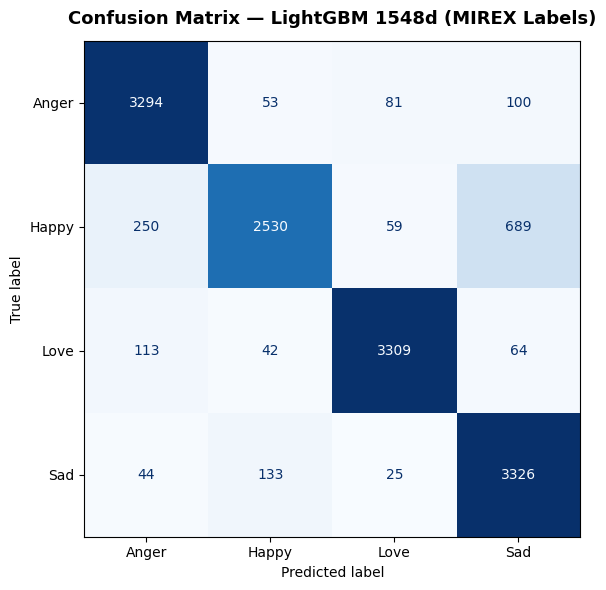

Saved: confusion_matrix_lgbm_1548d.png


In [75]:

# ── Confusion Matrix ──────────────────────────────────────────────────────
y_pred = lgbm_1548.predict(X_test)
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — LightGBM 1548d (MIREX Labels)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{path}/confusion_matrix_lgbm_1548d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_lgbm_1548d.png")


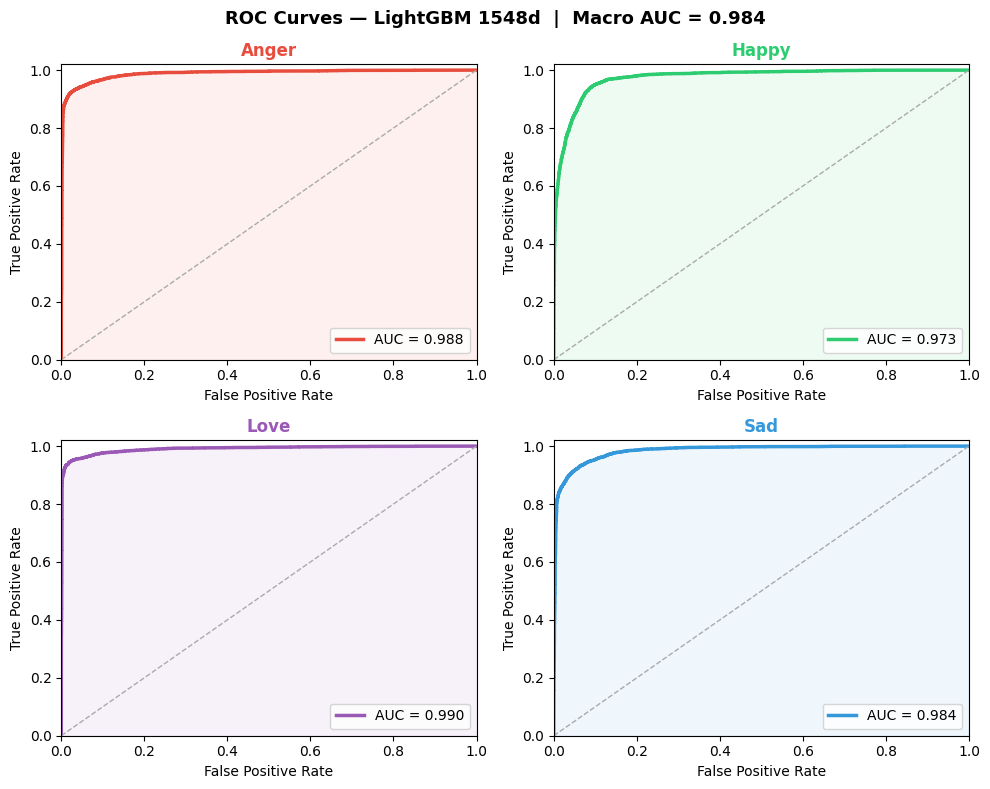

Macro AUC: 0.9839
Saved: roc_curves_lgbm_1548d.png


In [76]:

# ── ROC Curves (one-vs-rest, 4 classes) ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
aucs = []

for i, cls in enumerate(classes):
    color = palette[cls]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    aucs.append(auc)
    axes[i].plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {auc:.3f}')
    axes[i].plot([0, 1], [0, 1], '--', color='#aaaaaa', lw=1)
    axes[i].fill_between(fpr, tpr, alpha=0.08, color=color)
    axes[i].set_title(cls, fontweight='bold', color=color, fontsize=12)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right', fontsize=10)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.02])

macro_auc = np.mean(aucs)
fig.suptitle(f'ROC Curves — LightGBM 1548d  |  Macro AUC = {macro_auc:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{path}/roc_curves_lgbm_1548d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Macro AUC: {macro_auc:.4f}")
print("Saved: roc_curves_lgbm_1548d.png")


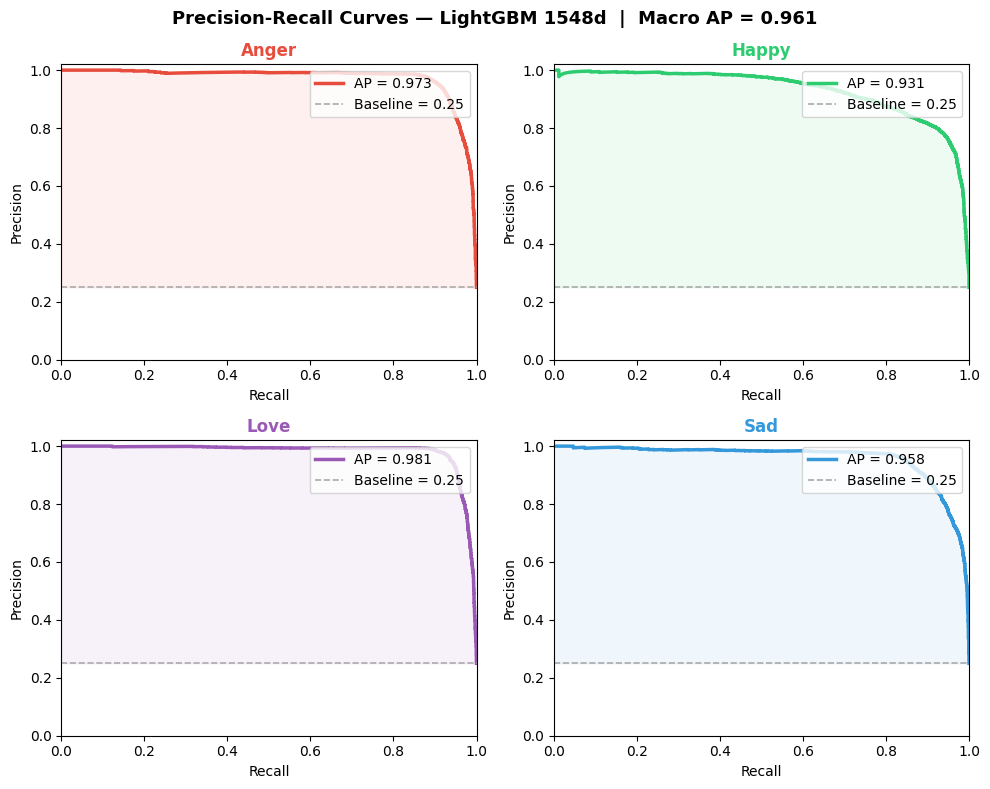

Macro AP: 0.9606
Saved: pr_curves_lgbm_1548d.png


In [77]:

# ── Precision-Recall Curves (one-vs-rest, 4 classes) ─────────────────────
from sklearn.metrics import average_precision_score

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
aps = []

for i, cls in enumerate(classes):
    color = palette[cls]
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    aps.append(ap)
    baseline = y_test_bin[:, i].mean()
    axes[i].plot(rec, prec, color=color, lw=2.5, label=f'AP = {ap:.3f}')
    axes[i].axhline(baseline, linestyle='--', color='#aaaaaa', lw=1.2,
                    label=f'Baseline = {baseline:.2f}')
    axes[i].fill_between(rec, prec, baseline, alpha=0.08, color=color)
    axes[i].set_title(cls, fontweight='bold', color=color, fontsize=12)
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend(loc='upper right', fontsize=10)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.02])

macro_ap = np.mean(aps)
fig.suptitle(f'Precision-Recall Curves — LightGBM 1548d  |  Macro AP = {macro_ap:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{path}/pr_curves_lgbm_1548d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Macro AP: {macro_ap:.4f}")
print("Saved: pr_curves_lgbm_1548d.png")


In [78]:

# ── SHAP Analysis — TreeExplainer + sample 500 test rows ─────────────────
audio_cols = ['danceability','energy','key','loudness','mode',
              'speechiness','acousticness','instrumentalness',
              'liveness','valence','tempo','duration_ms']
feature_names = [f'text_{i}' for i in range(1536)] + audio_cols

np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test), size=500, replace=False)
X_shap = X_test[shap_sample_idx]

print("Computing SHAP values via TreeExplainer (may take ~1-2 min on 500 samples × 1548 dims)...")
explainer = shap.TreeExplainer(lgbm_1548)
shap_vals = explainer.shap_values(X_shap)
# shap_vals: list of 4 arrays, each shape (500, 1548), one per class
print(f"Done. Shape per class: {shap_vals[0].shape}")
print(f"Classes: {classes.tolist()}")


Computing SHAP values via TreeExplainer (may take ~1-2 min on 500 samples × 1548 dims)...
Done. Shape per class: (1548, 4)
Classes: ['Anger', 'Happy', 'Love', 'Sad']


mean_shap shape: (1548,)


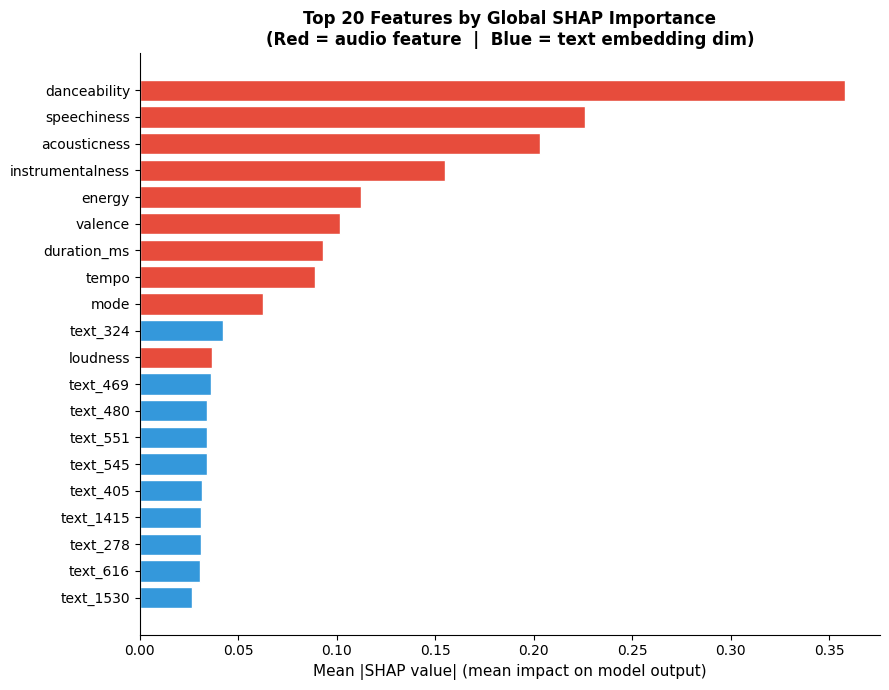


Audio feature rankings (out of 1548 total):
  danceability        : rank #   1  (mean |SHAP| = 0.358013)
  energy              : rank #   5  (mean |SHAP| = 0.112474)
  key                 : rank #  87  (mean |SHAP| = 0.012361)
  loudness            : rank #  11  (mean |SHAP| = 0.036945)
  mode                : rank #   9  (mean |SHAP| = 0.062515)
  speechiness         : rank #   2  (mean |SHAP| = 0.225971)
  acousticness        : rank #   3  (mean |SHAP| = 0.203123)
  instrumentalness    : rank #   4  (mean |SHAP| = 0.155062)
  liveness            : rank # 209  (mean |SHAP| = 0.008042)
  valence             : rank #   6  (mean |SHAP| = 0.101578)
  tempo               : rank #   8  (mean |SHAP| = 0.089158)
  duration_ms         : rank #   7  (mean |SHAP| = 0.093012)


In [80]:

# ── SHAP Global Feature Importance (top 20, all 1548 features) ───────────
# Handle both SHAP output formats:
#   list of n_classes arrays (n_samples, n_features)  — old SHAP
#   single 3D array (n_samples, n_features, n_classes) — new SHAP
if isinstance(shap_vals, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)  # (1548,)
else:
    mean_shap = np.abs(shap_vals).mean(axis=(0, 2))  # mean over samples & classes → (1548,)

print(f"mean_shap shape: {mean_shap.shape}")   # should be (1548,)

top_k    = 20
top_idx  = np.argsort(mean_shap)[-top_k:][::-1]
top_names = [feature_names[i] for i in top_idx]
top_vals  = mean_shap[top_idx]
bar_colors = ['#e74c3c' if not n.startswith('text_') else '#3498db' for n in top_names]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(top_k), top_vals[::-1], color=bar_colors[::-1], edgecolor='white')
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel('Mean |SHAP value| (mean impact on model output)', fontsize=11)
ax.set_title('Top 20 Features by Global SHAP Importance\n(Red = audio feature  |  Blue = text embedding dim)',
             fontweight='bold', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{path}/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Audio feature ranks within the full importance ranking
audio_start = 1536
print("\nAudio feature rankings (out of 1548 total):")
rank_all = np.argsort(mean_shap)[::-1]
for j, col in enumerate(audio_cols):
    rank = int(np.where(rank_all == audio_start + j)[0][0]) + 1
    print(f"  {col:20s}: rank #{rank:4d}  (mean |SHAP| = {mean_shap[audio_start+j]:.6f})")


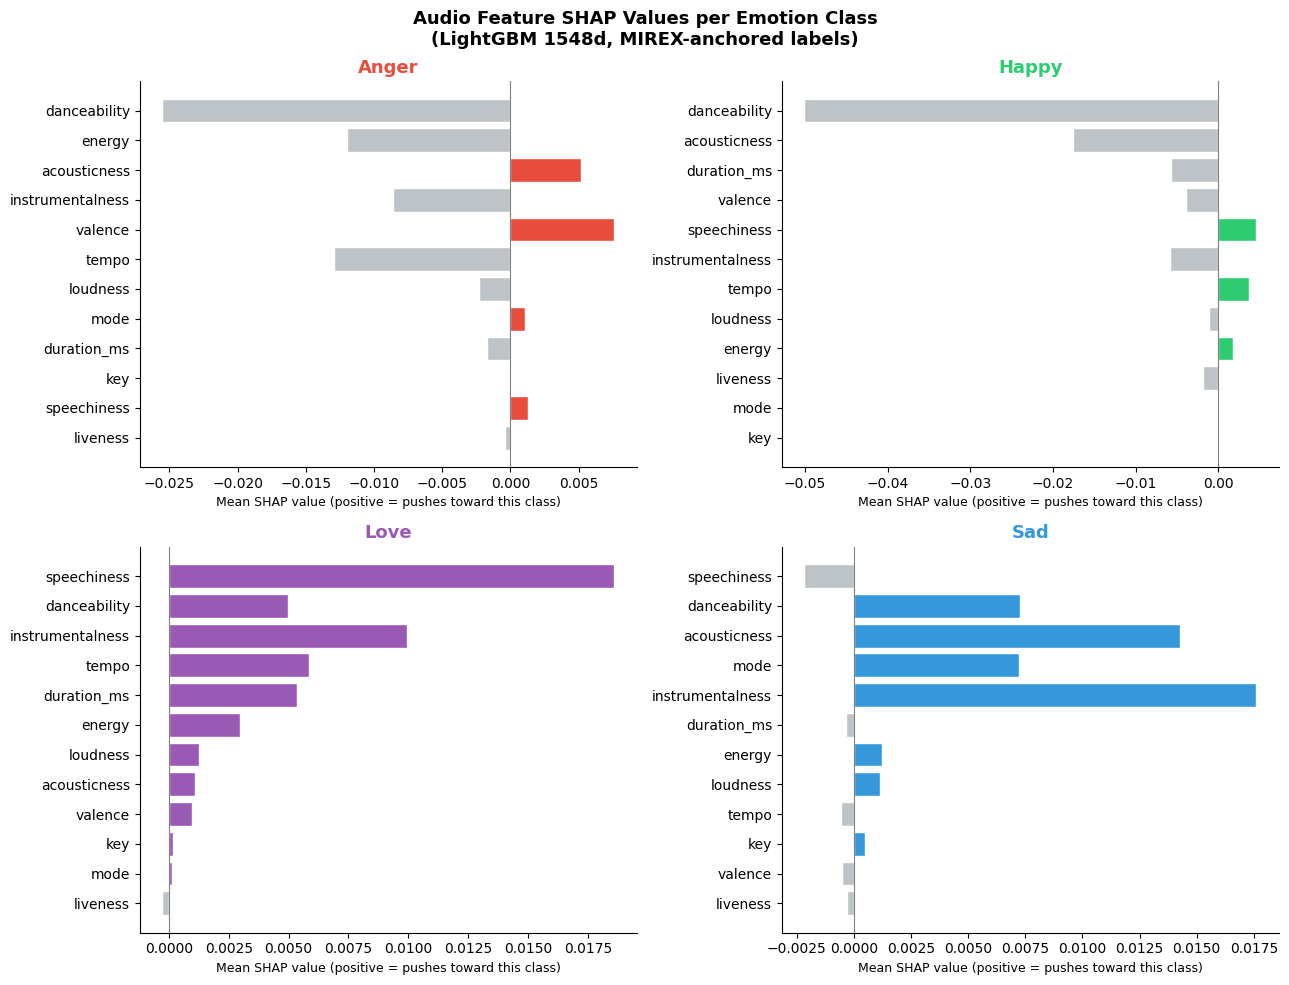

Saved: shap_audio_per_class.png


In [81]:

# ── SHAP Audio Features — Per-Class Breakdown ────────────────────────────
audio_idx = list(range(1536, 1548))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    color = palette[cls]

    # Extract audio-feature SHAP values for this class
    if isinstance(shap_vals, list):
        shap_audio = shap_vals[i][:, audio_idx]          # (500, 12)
    else:
        shap_audio = shap_vals[:, audio_idx, i]           # (500, 12)

    order = np.argsort(np.abs(shap_audio).mean(axis=0))  # ascending → least important at bottom
    mean_shap_cls = shap_audio.mean(axis=0)[order]
    names_ordered  = [audio_cols[j] for j in order]
    bar_c = [color if v >= 0 else '#bdc3c7' for v in mean_shap_cls]

    axes[i].barh(range(12), mean_shap_cls, color=bar_c, edgecolor='white')
    axes[i].set_yticks(range(12))
    axes[i].set_yticklabels(names_ordered, fontsize=10)
    axes[i].set_title(cls, fontweight='bold', color=color, fontsize=13)
    axes[i].set_xlabel('Mean SHAP value (positive = pushes toward this class)', fontsize=9)
    axes[i].axvline(0, color='black', lw=0.8, alpha=0.5)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Audio Feature SHAP Values per Emotion Class\n(LightGBM 1548d, MIREX-anchored labels)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{path}/shap_audio_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_audio_per_class.png")


## Section 11: VADER Experiment (1552d) — Negative Result
Add 4 VADER sentiment scores giving 1552d total.  
Result: 67.05% — VADER adds no improvement, slightly hurts performance.

In [169]:
sia = SentimentIntensityAnalyzer()

vader_scores = [sia.polarity_scores(str(lyrics)[:2000])
                for lyrics in tqdm(df_balanced['lyrics'], desc="VADER")]

vader_features = np.array([[s['pos'], s['neg'], s['neu'], s['compound']]
                            for s in vader_scores])

VADER: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120000/120000 [02:32<00:00, 785.79it/s]


In [170]:
vader_scaled = StandardScaler().fit_transform(vader_features)

In [171]:
combined_1552 = np.hstack([text_embeddings_1536, audio_scaled, vader_scaled])
print(f"Combined shape: {combined_1552.shape}")

Combined shape: (120000, 1552)


In [172]:
combined_1552_rebalanced = combined_1552[rebalanced_indices]
np.save(f'{path}/combined_embeddings_70k_1552d.npy', combined_1552_rebalanced)
print(f"Rebalanced: {combined_1552_rebalanced.shape}") 

Rebalanced: (70568, 1552)


In [177]:
X = combined_1552_rebalanced
y = df_rebalanced['emotion'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [178]:
lgbm_1552 = lgb.LGBMClassifier(
    n_estimators=1000,
    num_leaves=63,
    learning_rate=0.05,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1)

lgbm_1552.fit(X_train, y_train)
y_pred = lgbm_1552.predict(X_test)

In [179]:
print(f"LightGBM 1552d Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

LightGBM 1552d Accuracy: 0.6705
              precision    recall  f1-score   support

       Anger       0.69      0.66      0.67      3529
       Happy       0.67      0.66      0.66      3528
        Love       0.78      0.67      0.72      3529
         Sad       0.58      0.69      0.63      3528

    accuracy                           0.67     14114
   macro avg       0.68      0.67      0.67     14114
weighted avg       0.68      0.67      0.67     14114



## Section 12: MLP Experiment — Negative Result
MLP on 1548d features. Overfits due to insufficient dataset size (~70K samples).  
Result: lower than LightGBM — LightGBM remains the best model.

In [180]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_1548, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [181]:
inputs = keras.Input(shape=(1548,))
x = keras.layers.Dense(512, activation='relu')(inputs)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1548)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       793,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961,412 (3.67 MB)

 Trainable params: 959,620 (3.66 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [185]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=200,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6702 - loss: 0.7765 - val_accuracy: 0.6396 - val_loss: 0.8318
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6826 - loss: 0.7487 - val_accuracy: 0.6399 - val_loss: 0.8350
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6901 - loss: 0.7266 - val_accuracy: 0.6520 - val_loss: 0.8263
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6990 - loss: 0.6999 - val_accuracy: 0.6458 - val_loss: 0.8500
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7082 - loss: 0.6757 - val_accuracy: 0.6456 - val_loss: 0.8533
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7184 - loss: 0.6525 - val_accuracy: 0.6443 - val_loss: 0.8578
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7203 - loss: 0.6486 - val_accuracy: 0.6433 - val_loss: 0.8604
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7353 - loss: 0.6189 - val_accu

In [186]:
y_pred_mlp = le.inverse_transform(model.predict(X_test).argmax(axis=1))
y_test_labels = le.inverse_transform(y_test)

442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step


In [187]:
print(f"MLP Accuracy: {accuracy_score(y_test_labels, y_pred_mlp):.4f}")
print(classification_report(y_test_labels, y_pred_mlp))

MLP Accuracy: 0.6573
              precision    recall  f1-score   support

       Anger       0.74      0.58      0.65      3529
       Happy       0.62      0.70      0.66      3528
        Love       0.69      0.75      0.72      3529
         Sad       0.60      0.59      0.60      3528

    accuracy                           0.66     14114
   macro avg       0.66      0.66      0.66     14114
weighted avg       0.66      0.66      0.66     14114



## Section 13: Save Best Model
Save lgbm_1548 (67.18% accuracy) — loaded by inference.py in the application layer.

In [189]:
with open(f'{path}/lgbm_mirex_1548d.pkl', 'wb') as f:                                                                                                                                                                                           
    pickle.dump(lgbm_1548, f)                                                                                                                                                                                                                 
                                                                                                                                                                                                                                                  
print("Saved. Classes:", lgbm_1548.classes_)  

Saved. Classes: ['Anger' 'Happy' 'Love' 'Sad']


## Section 14: Inference Pipeline
All inference functions are defined in inference.py.  
Import and test below.

In [ ]:
from inference import classify_song

In [276]:
result = classify_song("Bad Romance", "Lady Gaga")
print(result)

Bad Romance,Lady Gaga
Result: "Bad Romance" by Lady Gaga:
    Oh, caught in a bad romance
    Oh, caught in a bad romance
    
    Ra, ra, ah-ah-ah
    Roma, roma-ma
    Gaga, ooh, l...
Lyrics: Oh, caught in a bad romance
Oh, caught in a bad romance

Ra, ra, ah-ah-ah
Roma, roma-ma
Gaga, ooh, l
{'emotion': 'Anger', 'confidence': 0.8921, 'probabilities': {'Anger': 0.8921, 'Happy': 0.0396, 'Love': 0.036, 'Sad': 0.0323}, 'track': {'id': '0SiywuOBRcynK0uKGWdCnn', 'name': 'Bad Romance', 'artist': 'Lady Gaga', 'embed_url': 'https://open.spotify.com/embed/track/0SiywuOBRcynK0uKGWdCnn?utm_source=generator'}, 'lyrics_found': True}


In [285]:
result = classify_song("Until I Found You","Stephen Sanchez")
print(result)

{'emotion': 'Sad', 'confidence': 0.9233, 'probabilities': {'Anger': 0.0217, 'Happy': 0.0228, 'Love': 0.0321, 'Sad': 0.9233}, 'track': {'id': '1Y3LN4zO1Edc2EluIoSPJN', 'name': 'Until I Found You (with Em Beihold) - Em Beihold Version', 'artist': 'Stephen Sanchez', 'embed_url': 'https://open.spotify.com/embed/track/1Y3LN4zO1Edc2EluIoSPJN?utm_source=generator'}, 'lyrics_found': True}


In [286]:
result = classify_song("My Heart Will Go On","Celine Dion")
print(result)

{'emotion': 'Happy', 'confidence': 0.5907, 'probabilities': {'Anger': 0.0063, 'Happy': 0.5907, 'Love': 0.0558, 'Sad': 0.3472}, 'track': {'id': '7F1yVPuJ4xRdrDvf8OL0HF', 'name': 'My Heart Will Go On - Love Theme from "Titanic"', 'artist': 'Céline Dion', 'embed_url': 'https://open.spotify.com/embed/track/7F1yVPuJ4xRdrDvf8OL0HF?utm_source=generator'}, 'lyrics_found': True}
